<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB18 · Aprender imitando: el aprendizaje supervisado

**Parte 2 · Matemáticas y herramientas para robots — Lección 7**

> En el **NB17** escribiste el algoritmo más importante de la inteligencia artificial: **seguir el gradiente**. Lo usaste para que el palo de
> escoba subiera por la montaña de su retorno. Pero viste el problema: cada paso cuesta **2 evaluaciones por ruedecilla**, y con miles de
> ruedecillas eso es carísimo.

Hoy vamos a ver una forma de aprender **distinta**, muy potente, y en la que ese problema **desaparece**: aprender **imitando** a un maestro.

En vez de que el robot pruebe y se guíe por la recompensa, le enseñaremos **ejemplos** de lo que hace alguien que ya sabe: "en esta situación,
el maestro empujó tanto". Y el robot ajustará sus ruedecillas para **parecerse** al maestro lo más posible. A esto se le llama **aprendizaje
supervisado** (porque hay un "supervisor" que dice la respuesta correcta), y es la forma en la que aprenden la mayoría de las inteligencias
artificiales que conoces.

En esta lección:

- Grabarás ejemplos de la política buena del palo de escoba.
- Medirás cuánto se equivoca una neurona con un número: el **error cuadrático medio**.
- Descubrirás la **regla de la cadena**, que permite calcular **todas las pendientes de golpe**.
- Y verás a la neurona **redescubrir sola** los números −30 y −8.


## 1 · Dos formas de aprender

Piensa en cómo aprendes las cosas en la vida:

- **Probando** (aprendizaje por refuerzo): aprendes a montar en bici cayéndote y volviendo a subir. Nadie te dice qué hacer en cada
  instante; solo sabes si te caes o no (la recompensa). Lento, pero no necesitas a nadie.
- **Imitando** (aprendizaje supervisado): aprendes a cocinar viendo a alguien que sabe, o a conducir mirando a tu padre o a tu madre, y
  luego intentando hacer **lo mismo** que ellos. Mucho más rápido... pero necesitas un **maestro** que ya sepa.

| | Aprender probando (refuerzo) | Aprender imitando (supervisado) |
|---|---|---|
| ¿Qué recibe el robot? | Una **recompensa**: "bien" o "mal" | La **respuesta correcta**: "aquí había que hacer esto" |
| ¿Necesita un maestro? | No | Sí |
| ¿Puede superar al maestro? | Sí | Difícilmente: como mucho, lo iguala |
| Velocidad | Lento (millones de intentos) | Rápido |

En robótica se usan **las dos**, y muchas veces **juntas**: primero el robot imita (por ejemplo, grabaciones de personas andando) para
empezar con una política razonable, y luego practica con refuerzo para mejorarla. Hoy vamos a por la imitación.

¿Y quién es nuestro maestro? La política **escrita a mano** del NB11, la que mantenía el palo de pie: empuje = −30 × inclinación − 8 ×
velocidad. El alumno será una neurona (NB13) que **no sabe** esos números. Si aprende bien, debería descubrirlos.


## 2 · Grabar los ejemplos del maestro

Primero necesitamos **ejemplos**: situaciones (observaciones) y lo que el maestro hizo en cada una. Pondremos al maestro a jugar 3 episodios
del palo de escoba, de 100 pasos cada uno, y en cada paso apuntaremos tres números en tres listas: la **inclinación**, la **velocidad** y el
**empuje** que decidió el maestro.

El mundo es el del NB11 (sin batería, como en el original). El código ya lo conoces; lo nuevo son solo las tres listas:


In [1]:
import random
import numpy as np

def maestro(inclinacion, velocidad):
    return -30 * inclinacion - 8 * velocidad

inclinaciones = []
velocidades = []
empujes_del_maestro = []

for semilla in range(3):
    random.seed(semilla)
    inclinacion = 2.0
    velocidad = 0.0
    for n in range(100):
        empuje = maestro(inclinacion, velocidad)
        # apuntamos el ejemplo: la situación y lo que hizo el maestro
        inclinaciones.append(inclinacion)
        velocidades.append(velocidad)
        empujes_del_maestro.append(empuje)
        # y el mundo avanza, como en el NB11
        empuje = max(-40, min(40, empuje))
        aceleracion = 10 * inclinacion + empuje + random.uniform(-30, 30)
        velocidad = velocidad + aceleracion * 0.02
        inclinacion = inclinacion + velocidad * 0.02

inclinaciones = np.array(inclinaciones)
velocidades = np.array(velocidades)
empujes_del_maestro = np.array(empujes_del_maestro)
print("Ejemplos grabados:", len(empujes_del_maestro))

Ejemplos grabados: 300


(Una pequeña novedad: `max(-40, min(40, empuje))` recorta el empuje a ±40 en una sola línea: `min` se queda con el menor entre 40 y el
empuje, y `max`, con el mayor entre −40 y eso. Es lo mismo que los dos `if` del NB11.)

**300 ejemplos**, y al final los hemos convertido en arrays de NumPy (NB15) para calcular cómodamente. A este conjunto de ejemplos se le llama
**datos de entrenamiento** (o **conjunto de datos**, en inglés *dataset*). Miremos los cinco primeros:


In [2]:
for k in range(5):
    print("inclinación", round(inclinaciones[k], 3), "| velocidad", round(velocidades[k], 3),
          "| el maestro empujó", round(empujes_del_maestro[k], 2))

inclinación 2.0 | velocidad 0.0 | el maestro empujó -60.0
inclinación 2.0 | velocidad 0.013 | el maestro empujó -60.11
inclinación 1.999 | velocidad -0.077 | el maestro empujó -59.34
inclinación 1.987 | velocidad -0.573 | el maestro empujó -55.04
inclinación 1.962 | velocidad -1.265 | el maestro empujó -48.74


Cada fila es un ejemplo: "en **esta** situación, el maestro empujó **esto**". Al principio el palo está inclinado 2 grados y el maestro empuja
con fuerza (−60) para enderezarlo; enseguida el palo empieza a moverse y el maestro ajusta. Al empuje del maestro, que es "la respuesta
correcta", se le llama **etiqueta** (como la etiqueta de la solución pegada a cada ejercicio).


## 3 · El alumno, y cuánto se equivoca

El **alumno** es una neurona (NB13) con dos pesos, `w1` (para la inclinación) y `w2` (para la velocidad), y un sesgo `b`. Su respuesta, para
cada ejemplo, es su **predicción**: lo que **él** empujaría.

```
   predicción = w1 × inclinación + w2 × velocidad + b
```

Al principio no sabe nada: todo a 0. Así que siempre predice "empuja 0". ¿Cómo de mal lo hace? Para cada ejemplo, el **error** es la
diferencia entre lo que predice y lo que hizo el maestro:

```
   error = predicción − lo que hizo el maestro
```

Pero tenemos 300 ejemplos, y queremos **un solo número** que diga "cuánto se equivoca en total". Podríamos hacer la media de los errores... pero
hay un problema: unos errores son positivos (empujó de más) y otros negativos (empujó de menos), y **se compensarían**, dando una media
engañosamente pequeña. La solución ya la conoces del NB04: **elevar al cuadrado**. El cuadrado se come el signo y además castiga mucho más los
errores grandes que los pequeños. Así que:

> **Error cuadrático medio** = la **media** de los **errores al cuadrado** de todos los ejemplos.

Es el número que mide "cuánto se equivoca el alumno", y al que se le llama **pérdida** (en inglés, *loss*). **Cuanto más pequeña, mejor**: una
pérdida de 0 significaría que el alumno imita **perfectamente** al maestro. Con NumPy (NB15) se calcula en una línea, para los 300 ejemplos a la
vez:


In [3]:
def perdida(w1, w2, b):
    predicciones = w1 * inclinaciones + w2 * velocidades + b
    errores = predicciones - empujes_del_maestro
    return np.mean(errores ** 2)

print("Pérdida del alumno que no sabe nada (todo a 0):", round(perdida(0, 0, 0), 1))
print("Pérdida si acertara los pesos del maestro:     ", round(perdida(-30, -8, 0), 1))

Pérdida del alumno que no sabe nada (todo a 0): 305.6
Pérdida si acertara los pesos del maestro:      0.0


El alumno ignorante tiene una pérdida de **305,6**. Y si tuviera exactamente los pesos del maestro (−30, −8, 0), la pérdida sería **0**: imitación
perfecta. **El objetivo del aprendizaje es bajar la pérdida de 305,6 a 0.** Y para bajar... ¡descenso por gradiente (NB17)!


## 4 · La pérdida es un valle

En el NB17 subíamos una **montaña** (el retorno: cuanto más, mejor). Ahora queremos **bajar a un valle** (la pérdida: cuanto menos, mejor). Es lo
mismo con el signo cambiado: en vez de x + tasa × pendiente, **x − tasa × pendiente** (ir **en contra** de la pendiente es ir cuesta abajo; ejercicio
E2 del NB17).

Dibujemos el valle. Dejamos `w2` en −8 y `b` en 0, y miramos cómo cambia la pérdida al mover solo `w1`:


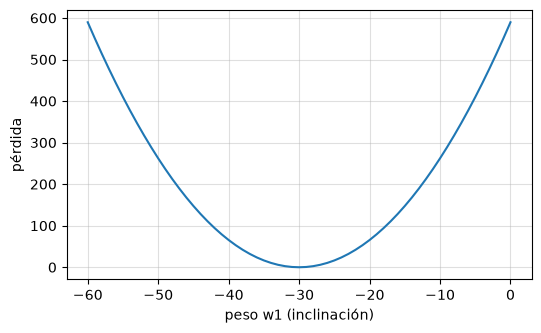

In [4]:
import matplotlib.pyplot as plt

valores_w1 = []
perdidas = []
for i in range(-60, 1):
    valores_w1.append(i)
    perdidas.append(perdida(i, -8, 0))

plt.figure(figsize=(6, 3.5))
plt.plot(valores_w1, perdidas, color="tab:blue")
plt.grid(True, alpha=0.4)
plt.xlabel("peso w1 (inclinación)")
plt.ylabel("pérdida")
plt.show()

¡Una parábola (NB16), con el fondo **justo en −30**! Ahí la pérdida es 0. Si el peso es menor o mayor, el alumno empuja de más o de menos, y la
pérdida sube. Encontrar el fondo de este valle es encontrar el peso del maestro.

Podríamos bajar con el **gradiente numérico** del NB17 (moviendo cada ruedecilla un poquito a cada lado). Funcionaría. Pero hoy vamos a aprender
algo mucho mejor: calcular la pendiente **exacta**, de **todas** las ruedecillas, **de golpe**. Para eso necesitamos una idea nueva.


## 5 · La regla de la cadena: engranajes

Imagina tres **engranajes** conectados: A mueve a B, y B mueve a C.

```
       A ────► B ────► C
     (si A gira 1 vuelta, B gira 2)    (si B gira 1 vuelta, C gira 3)

     ¿Cuánto gira C si A gira 1 vuelta?   →   2 × 3 = 6 vueltas
```

Si cada vuelta de A da **2** vueltas de B, y cada vuelta de B da **3** de C, entonces cada vuelta de A da **2 × 3 = 6** vueltas de C. Para saber
cuánto afecta A a C, **se multiplican** los efectos de cada eslabón de la cadena.

Eso es la **regla de la cadena**, una de las reglas más importantes del cálculo: **cuando una cosa afecta a otra a través de pasos intermedios,
la pendiente total es el producto de las pendientes de cada paso.**

Apliquémosla a nuestra pérdida. ¿Cómo afecta el peso `w1` a la pérdida? A través de una cadena:

```
   w1  ────►  predicción  ────►  error  ────►  error al cuadrado (la pérdida de ese ejemplo)
```

Eslabón a eslabón:

1. **w1 → predicción.** La predicción es w1 × inclinación + ... Si w1 aumenta 1, la predicción aumenta **inclinación** (lo que valga la inclinación
   de ese ejemplo). Pendiente de este eslabón: **la inclinación**.
2. **predicción → error.** El error es predicción − maestro. Si la predicción sube 1, el error sube 1. Pendiente: **1**.
3. **error → error al cuadrado.** ¡Esto lo descubriste en el NB16! La pendiente de x² es **2x**. Así que la pendiente de error² es **2 × error**.

Multiplicando los eslabones, como los engranajes:

```
   pendiente de la pérdida respecto a w1 (en un ejemplo)  =  inclinación × 1 × 2 × error  =  2 × error × inclinación
```

Y como la pérdida total es la **media** de todos los ejemplos, su pendiente es la **media** de las pendientes de cada ejemplo:

> **pendiente respecto a w1 = 2 × media( error × inclinación )**
> **pendiente respecto a w2 = 2 × media( error × velocidad )**
> **pendiente respecto a b  = 2 × media( error )** (el sesgo no se multiplica por nada: su "entrada" es siempre 1)

Fíjate en lo que dice la fórmula, porque tiene todo el sentido: **cada ejemplo empuja cada peso en proporción a su error y a su entrada**. Si en
un ejemplo el alumno empujó de más (error positivo) y la inclinación era grande, ese peso tiene mucha "culpa" y hay que corregirlo bastante. Si la
inclinación era casi 0, ese peso apenas influyó en el error, y apenas se toca. **Es la asignación del mérito del NB04, resuelta con matemáticas.**


### Comprobémoslo

Una regla nueva no se cree: se **comprueba** (NB07). Calculemos la pendiente respecto a w1 de las dos maneras, en un punto cualquiera (por
ejemplo, w1 = −10, w2 = −2, b = 0): con el gradiente numérico del NB17, y con la fórmula de la regla de la cadena:


In [5]:
w1, w2, b = -10.0, -2.0, 0.0

# Forma 1: gradiente numérico (mover w1 un poquito a cada lado, NB16-17)
h = 0.0001
numerica = (perdida(w1 + h, w2, b) - perdida(w1 - h, w2, b)) / (2 * h)

# Forma 2: la regla de la cadena
errores = (w1 * inclinaciones + w2 * velocidades + b) - empujes_del_maestro
exacta = 2 * np.mean(errores * inclinaciones)

print("Pendiente numérica:            ", round(numerica, 4))
print("Pendiente con regla de cadena: ", round(exacta, 4))

Pendiente numérica:             14.7596
Pendiente con regla de cadena:  14.7596


**¡Idénticas!** (14,7596 las dos.) La regla de la cadena funciona.

¿Y cuál es la gran ventaja? Mira la **forma 2**: con **una sola** pasada por los datos (calcular los errores una vez) obtenemos la pendiente de w1;
y con esos **mismos** errores, multiplicando por las velocidades, la de w2; y haciendo su media, la de b. **Todas las pendientes de golpe**, sin
tener que mover cada ruedecilla por separado. Con 3 ruedecillas no se nota mucho. Con 5.933 (o con los millones de una red grande), la diferencia
es la que hay entre **posible** e **imposible**.

Esta idea, aplicar la regla de la cadena hacia atrás, eslabón a eslabón, para calcular de golpe las pendientes de todos los pesos, es la famosa
**retropropagación** que anunciamos en el NB17 (en inglés, *backpropagation*: "propagar hacia atrás"). En una red de varias capas la cadena es más
larga, pero la idea es exactamente la de los engranajes.


## 6 · ¡A entrenar!

Ya tenemos todo. El bucle de entrenamiento: empezar con todo a 0, y en cada paso, calcular los errores, las tres pendientes con la regla de la
cadena, y **bajar** (restar tasa × pendiente). Guardamos la pérdida de cada paso para dibujarla después:


In [6]:
w1, w2, b = 0.0, 0.0, 0.0
tasa = 0.2
historial = []

for paso in range(200):
    # 1. lo que predice el alumno, y cuánto se equivoca en cada ejemplo
    errores = (w1 * inclinaciones + w2 * velocidades + b) - empujes_del_maestro
    historial.append(np.mean(errores ** 2))
    # 2. todas las pendientes de golpe (regla de la cadena)
    pendiente_w1 = 2 * np.mean(errores * inclinaciones)
    pendiente_w2 = 2 * np.mean(errores * velocidades)
    pendiente_b = 2 * np.mean(errores)
    # 3. un paso cuesta ABAJO (descenso por gradiente)
    w1 = w1 - tasa * pendiente_w1
    w2 = w2 - tasa * pendiente_w2
    b = b - tasa * pendiente_b

print("Pesos aprendidos: w1 =", round(w1, 3), "| w2 =", round(w2, 3), "| b =", round(b, 3))
print("Pérdida final:", perdida(w1, w2, b))

Pesos aprendidos: w1 = -30.0 | w2 = -8.0 | b = -0.0
Pérdida final: 2.2590615227401666e-13


**w1 = −30, w2 = −8, b = 0.** ¡El alumno ha **redescubierto** exactamente los números del maestro! Nadie se los ha dicho: solo ha visto 300
ejemplos de lo que hacía el maestro, y ha bajado por la pendiente de su error hasta imitarlo perfectamente. La pérdida final es un número minúsculo
(en notación científica, NB14: prácticamente 0).

Esta es la **curva de aprendizaje**, la pérdida paso a paso:


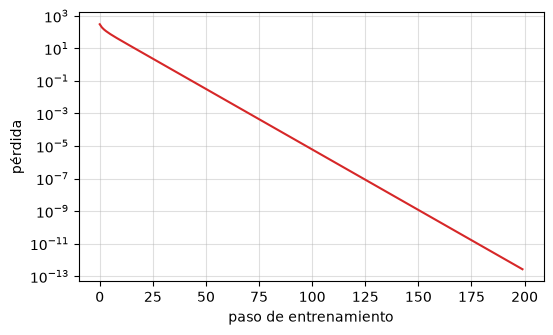

In [7]:
plt.figure(figsize=(6, 3.5))
plt.plot(historial, color="tab:red")
plt.grid(True, alpha=0.4)
plt.xlabel("paso de entrenamiento")
plt.ylabel("pérdida")
plt.yscale("log")         # escala especial: cada raya es 10 veces menos que la anterior
plt.show()

La pérdida **baja sin parar**, de 305 a casi cero. (Hemos usado una **escala logarítmica** en el eje vertical, NB15b: en vez de ir de 10 en 10, cada raya
es **10 veces** más pequeña que la anterior, 100, 10, 1, 0,1... Así se ve bien una caída tan enorme. Es la escala que usan los profesionales para
mirar curvas de aprendizaje.)

**Mirar esta curva es lo primero que hace cualquier ingeniero** mientras entrena una red: si baja, todo va bien; si se estanca, algo falla; y si
**sube**... cuidado.


### La tasa, otra vez

¿Recuerdas que en el NB17 una tasa demasiado grande hacía **explotar** el ascenso? Probemos aquí con tasa **0,3** en vez de 0,2. Una función que
entrena con la tasa que le digamos y devuelve los pesos y la pérdida final:


In [8]:
def entrenar(tasa, pasos):
    w1, w2, b = 0.0, 0.0, 0.0
    for paso in range(pasos):
        errores = (w1 * inclinaciones + w2 * velocidades + b) - empujes_del_maestro
        w1 = w1 - tasa * 2 * np.mean(errores * inclinaciones)
        w2 = w2 - tasa * 2 * np.mean(errores * velocidades)
        b = b - tasa * 2 * np.mean(errores)
    return w1, w2, b

for tasa in [0.01, 0.2, 0.3]:
    w1, w2, b = entrenar(tasa, 200)
    print("tasa", tasa, "-> w1 =", round(w1, 2), "| w2 =", round(w2, 2), "| pérdida =", perdida(w1, w2, b))

tasa 0.01 -> w1 = -18.46 | w2 = -5.01 | pérdida = 32.97279419646307
tasa 0.2 -> w1 = -30.0 | w2 = -8.0 | pérdida = 2.2590615227401666e-13
tasa 0.3 -> w1 = 476021959.28 | w2 = -1137204283.46 | pérdida = 6.213088272161967e+18


- Con **0,01**, tras 200 pasos aún va por la mitad del camino (w1 ≈ −18): demasiado lenta.
- Con **0,2**, perfecta.
- Con **0,3**, ¡**explota**! Los pesos se disparan a cientos de millones y la pérdida a un número con **18 cifras** (`e+18`). Con solo subir la tasa
  de 0,2 a 0,3.

La frontera entre "aprende perfectamente" y "explota" puede ser **así de fina**. Por eso los profesionales vigilan la curva de aprendizaje y, si
ven que la pérdida se dispara, lo primero que hacen es **bajar la tasa**.


## 7 · El alumno juega

Que el alumno imite al maestro **en los ejemplos** está muy bien. Pero lo que de verdad importa es: **¿sabe mantener el palo de pie?** Vamos a
ponerlo a jugar en el mundo del NB11, con sus pesos aprendidos como política (y otra vez la media de 5 episodios, como en el NB11):


In [9]:
def evaluar(w1, w2, b):
    total = 0
    for semilla in range(5):
        random.seed(semilla)
        inclinacion = 2.0
        velocidad = 0.0
        for n in range(500):
            empuje = w1 * inclinacion + w2 * velocidad + b        # LA POLÍTICA DEL ALUMNO
            empuje = max(-40, min(40, empuje))
            aceleracion = 10 * inclinacion + empuje + random.uniform(-30, 30)
            velocidad = velocidad + aceleracion * 0.02
            inclinacion = inclinacion + velocidad * 0.02
            if inclinacion > 30 or inclinacion < -30:
                break
            total = total + 1 - (inclinacion / 30) ** 2
    return total / 5

w1, w2, b = entrenar(0.2, 200)
print("El alumno bien entrenado:", round(evaluar(w1, w2, b), 1), "puntos")

w1, w2, b = entrenar(0.01, 200)
print("El alumno a medio aprender (w1 =", round(w1, 1), ", w2 =", round(w2, 1), "):", round(evaluar(w1, w2, b), 1), "puntos")

El alumno bien entrenado: 499.9 puntos
El alumno a medio aprender (w1 = -18.5 , w2 = -5.0 ): 499.8 puntos


El alumno bien entrenado saca **499,9**, exactamente como el maestro (lógico: tiene sus mismos pesos). Y fíjate en el segundo: el alumno **a medio
aprender**, con unos pesos que aún están lejos de los del maestro, ¡**también** mantiene el palo de pie (499,8)! No hace falta imitar al maestro
perfectamente; basta con parecerse **lo suficiente**. (Recuerda el NB11: había muchísimas combinaciones de ruedecillas que funcionaban.)

**Ha aprendido a mantener el palo de pie sin jugar ni un solo episodio**, solo mirando cómo lo hacía otro. Esa es la fuerza de la imitación.


## 8 · Un maestro que no es perfecto

En la vida real, los maestros se equivocan. Si grabas a una persona manejando un robot con un mando, a veces empujará un poco de más y a veces un
poco de menos. ¿Qué aprende el alumno de un maestro imperfecto?

Vamos a "estropear" las etiquetas: a cada empuje del maestro le sumamos un error al azar entre −10 y +10, como si tuviera el pulso tembloroso. Y
entrenamos otra vez, con más pasos:


In [10]:
random.seed(99)
empujes_limpios = empujes_del_maestro.copy()          # guardamos los buenos para luego
temblores = []
for k in range(len(empujes_del_maestro)):
    temblores.append(random.uniform(-10, 10))
empujes_del_maestro = empujes_limpios + np.array(temblores)

w1, w2, b = entrenar(0.2, 500)
print("Con un maestro tembloroso: w1 =", round(w1, 2), "| w2 =", round(w2, 2), "| b =", round(b, 2))
print("Pérdida final:", round(perdida(w1, w2, b), 1))

empujes_del_maestro = empujes_limpios                  # dejamos los datos como estaban

Con un maestro tembloroso: w1 = -29.7 | w2 = -7.97 | b = -0.3
Pérdida final: 31.5


(`.copy()` hace una **copia** del array, para poder recuperar los datos buenos al final. Si no, `empujes_limpios` y `empujes_del_maestro` serían el
mismo array con dos nombres, y al cambiar uno cambiaría el otro.)

El alumno aprende **w1 ≈ −29,7 y w2 ≈ −8,0**: muy cerca de los −30 y −8 de verdad, aunque **ningún** ejemplo tenía el empuje exacto. Los temblores son
al azar, unos hacia arriba y otros hacia abajo, y al hacer la media de muchos ejemplos **se compensan**. El alumno ha aprendido "lo que el maestro
**quería** hacer", no sus temblores. (La pérdida ya no baja a 0, sino a unos 31: es el error que no se puede eliminar, porque los temblores son puro
azar.) Por eso, en aprendizaje supervisado, **más datos** suelen dar mejores resultados: más ejemplos, más se compensan los errores.


## 9 · El punto débil de imitar

La imitación tiene un problema famoso, y es importante que lo conozcas. Fíjate en los datos que hemos grabado: el maestro es **muy bueno**, así que el
palo casi siempre estuvo **casi derecho**. El alumno solo ha visto situaciones "tranquilas".

¿Qué pasa si el alumno, por un pequeño error, llega a una situación que el maestro **nunca** vivió (por ejemplo, el palo inclinado 20 grados)? No ha
visto ningún ejemplo así. En nuestro caso tenemos suerte: la política es una simple neurona lineal, y "extiende" su regla de forma razonable. Pero con
una política compleja (una red neuronal grande), el alumno podría hacer **cualquier disparate** en situaciones nuevas, que lo llevarían a situaciones
aún más raras, y así hasta caerse. Los errores se **acumulan**, como el ruido de los pasos del NB07.

A esto se le llama **desplazamiento de distribución** (en inglés, *distribution shift*): el alumno se encuentra con situaciones **distintas** de las que
vio al aprender. Es una de las razones por las que, en robótica, la imitación **se combina** con el aprendizaje por refuerzo: imitar da un buen punto de
partida, y practicar (refuerzo) enseña a recuperarse de los propios errores. (Y es pariente de la brecha de realidad del NB02: el mundo real también es
"una situación que no se vio al entrenar".)


## 10 · La imitación en los humanoides de verdad

Lo que has hecho hoy, a pequeña escala, se usa muchísimo con humanoides reales:

- Se **graban personas** moviéndose (andando, corriendo, bailando) con trajes llenos de sensores o con cámaras, y el robot aprende a **imitar** esos
  movimientos. A esto se le llama **imitación de movimiento**, y es una de las razones por las que algunos humanoides andan de una forma tan "humana".
- Se **manejan robots a distancia** (teleoperación: una persona controla el robot con un mando o con su propio cuerpo) mientras se graba todo, y luego el
  robot aprende de esas grabaciones a hacer la tarea **él solo**.
- Y casi siempre, después de imitar, el robot **practica con refuerzo** para mejorar y para aprender a recuperarse de sus propios errores.

El "maestro" cambia, la red neuronal es mucho más grande, pero el corazón es **exactamente** lo de hoy: ejemplos, una pérdida, la regla de la cadena y
el descenso por gradiente.


## 11 · Resumen de la lección

1. **Aprendizaje supervisado** (imitación): el alumno aprende de **ejemplos** con la respuesta correcta (**etiquetas**), en vez de una recompensa. Rápido,
   pero necesita un maestro. Grabamos **300 ejemplos** (datos de entrenamiento) de la política a mano del palo de escoba.
2. La **pérdida** mide cuánto se equivoca el alumno: el **error cuadrático medio** (media de los errores al cuadrado). Todo a 0: 305,6; con los pesos del
   maestro: 0. Aprender es **bajar al valle** de la pérdida (descenso por gradiente).
3. La **regla de la cadena** (engranajes: las pendientes de cada eslabón **se multiplican**) da las pendientes exactas: pendiente de w = **2 × media(error ×
   entrada)**. Coincide con la numérica y calcula **todas las pendientes de golpe**: es la base de la **retropropagación**.
4. Entrenando con tasa 0,2, el alumno **redescubre −30 y −8**, y mantiene el palo (499,9) sin haber jugado nunca. Con tasa 0,3, **explota**. La **curva de
   aprendizaje** (en escala logarítmica) muestra cómo baja la pérdida.
5. Con un maestro tembloroso, los errores al azar **se compensan** (aprende ≈ −29,7 y −8,0). El punto débil: el **desplazamiento de distribución** (el
   alumno solo sabe de las situaciones que vio). Por eso se combina con el refuerzo.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Aprendizaje supervisado** | Aprender de ejemplos con la respuesta correcta. |
| **Datos de entrenamiento (*dataset*)** | El conjunto de ejemplos para aprender. |
| **Etiqueta** | La respuesta correcta de cada ejemplo (aquí, el empuje del maestro). |
| **Predicción** | Lo que responde el alumno para un ejemplo. |
| **Error cuadrático medio** | La media de los errores al cuadrado. |
| **Pérdida (*loss*)** | El número que mide cuánto se equivoca el alumno; hay que hacerlo pequeño. |
| **Regla de la cadena** | Las pendientes de una cadena de pasos se multiplican (como engranajes). |
| **Retropropagación** | Aplicar la regla de la cadena hacia atrás para tener todas las pendientes de golpe. |
| **Curva de aprendizaje** | La pérdida dibujada paso a paso durante el entrenamiento. |
| **Escala logarítmica** | Un eje donde cada raya es 10 veces la anterior. |
| **Desplazamiento de distribución** | Encontrarse situaciones distintas de las vistas al aprender. |
| **Imitación de movimiento** | Robots que aprenden a moverse imitando grabaciones de personas. |


## 12 · Ejercicios

**E1.** Un alumno predice 10, 20 y 30 en tres ejemplos cuyas etiquetas son 12, 20 y 25. Calcula a mano su error cuadrático medio.

**E2.** ¿Por qué no usamos simplemente la media de los errores (sin elevar al cuadrado)? Pon un ejemplo con dos errores en el que la media de los
errores sea 0 aunque el alumno se equivoque mucho.

**E3.** Con los engranajes: si A → B tiene un efecto de 4 y B → C un efecto de 0,5, ¿cuánto se mueve C cuando A se mueve 1? ¿Y si B → C fuera −2?

**E4.** Entrena con tasa **0,25**. ¿Aprende o explota? (Pista: está entre 0,2 y 0,3.)

**E5.** Entrena con tasa 0,2 pero solo **10** pasos. ¿Qué pesos aprende? ¿Mantiene el palo de pie? Usa `evaluar`.

**E6.** **Reto.** Graba ejemplos de un maestro **distinto**: `-50 * inclinacion - 12 * velocidad`. (Tendrás que cambiar la función `maestro` y volver a
ejecutar la celda de grabar los ejemplos.) ¿Descubre el alumno los nuevos números?


<details>
<summary>▶ Solución E1</summary>

Errores: 10 − 12 = −2; 20 − 20 = 0; 30 − 25 = 5. Al cuadrado: 4, 0, 25. Media: (4 + 0 + 25) / 3 = 29 / 3 ≈ **9,67**.
</details>

<details>
<summary>▶ Solución E2</summary>

Porque los errores positivos y negativos **se compensan**. Ejemplo: el alumno predice 0 donde la etiqueta es 100 (error −100) y 200 donde la etiqueta es 100
(error +100). La media de los errores es (−100 + 100) / 2 = **0**: ¡parece perfecto! Pero se ha equivocado en 100 las dos veces. Con los cuadrados: (10.000 +
10.000) / 2 = 10.000, que sí refleja lo mal que lo hace.
</details>

<details>
<summary>▶ Solución E3</summary>

Se multiplican: 4 × 0,5 = **2**. Si A se mueve 1, C se mueve 2. Con B → C = −2: 4 × (−2) = **−8**: C se mueve 8, pero **al revés**. (Un engranaje con efecto
negativo invierte el sentido, como dos ruedas dentadas que encajan y giran en sentidos opuestos.)
</details>

<details>
<summary>▶ Solución E4</summary>

```python
w1, w2, b = entrenar(0.25, 200)
print(w1, w2, perdida(w1, w2, b))
```

Con **0,25** todavía **aprende**: llega a w1 = −30 y w2 = −8, con una pérdida minúscula. Así que la frontera entre "aprende" y "explota"
está entre **0,25 y 0,3**. Este tipo de prueba ("¿qué tasa es la más grande que no explota?") es algo que los profesionales hacen constantemente.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
w1, w2, b = entrenar(0.2, 10)
print(round(w1, 2), round(w2, 2), round(b, 2))
print(round(evaluar(w1, w2, b), 1))
```

Con solo 10 pasos, el alumno aprende algo como **w1 ≈ −18,9, w2 ≈ −5,2 y b ≈ −4,2**: aún lejos de −30 y −8. ¡Y sin embargo saca **499,8**
puntos! Como vimos en el apartado 7, no hace falta imitar perfectamente: basta con que el peso de la inclinación sea lo bastante grande (en negativo)
para vencer a la gravedad (NB11: la ruedecilla tiene que pasar de 10) y que frene la velocidad. Diez pasos de entrenamiento, una fracción de segundo,
y el palo ya no se cae.
</details>

<details>
<summary>▶ Solución E6</summary>

Cambia la función:

```python
def maestro(inclinacion, velocidad):
    return -50 * inclinacion - 12 * velocidad
```

vuelve a ejecutar la celda que graba los ejemplos (y las que convierten a arrays), y entrena. El alumno debería encontrar **w1 ≈ −50 y w2 ≈ −12**: aprende al maestro
que tenga delante, sea cual sea. (Si con tasa 0,2 explota, prueba a bajarla: con un maestro distinto, los datos cambian, y la frontera de la tasa también.) Es la
idea central del aprendizaje supervisado: **el mismo método aprende cualquier cosa que le enseñes con ejemplos**.
</details>


## 13 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Hoy has entrenado tu primera neurona con **datos**, has descubierto la **regla de la cadena** (el secreto de la retropropagación), y has visto a una neurona
redescubrir sola los números de su maestro. Es, a pequeña escala, exactamente lo que hacen las redes neuronales gigantes.

Pero nuestro alumno tiene un límite: es **una** neurona **lineal**. Solo sabe aprender reglas del tipo "empuja tanto por cada grado". ¿Y si el maestro hiciera
algo más complicado, que no se puede escribir como una suma con pesos? En el **NB19** descubriremos el ingrediente que le falta: la **función de activación**, el
pequeño "codo" que, puesto entre capa y capa, convierte un montón de neuronas lineales en una **red neuronal** capaz de aprender casi cualquier cosa.
